# Trend Following Parameter Sweep Results

Visualization of sweep results from `sweep.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as mtrans
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_rows', 100, 'display.max_columns', None)
RESULTS = Path('sweep_results')

/Users/chiao/miniconda3/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy.stats import gaussian_kde


In [2]:
# Load all results
singles = pd.read_parquet(RESULTS / 'singles.parquet') if (RESULTS / 'singles.parquet').exists() else pd.DataFrame()
by_cat = pd.read_parquet(RESULTS / 'by_category.parquet') if (RESULTS / 'by_category.parquet').exists() else pd.DataFrame()
es_overlay = pd.read_parquet(RESULTS / 'es_overlay.parquet') if (RESULTS / 'es_overlay.parquet').exists() else pd.DataFrame()
blends = pd.read_parquet(RESULTS / 'blends.parquet') if (RESULTS / 'blends.parquet').exists() else pd.DataFrame()
bootstrap = pd.read_parquet(RESULTS / 'bootstrap.parquet') if (RESULTS / 'bootstrap.parquet').exists() else pd.DataFrame()
dense = pd.read_parquet(RESULTS / 'dense.parquet') if (RESULTS / 'dense.parquet').exists() else pd.DataFrame()
composite = pd.read_parquet(RESULTS / 'composite.parquet') if (RESULTS / 'composite.parquet').exists() else pd.DataFrame()
composite_pnl = pd.read_parquet(RESULTS / 'composite_pnl.parquet') if (RESULTS / 'composite_pnl.parquet').exists() else pd.DataFrame()

SP500_VOL = 0.16
if len(composite_pnl) > 0:
    ann_vols = composite_pnl.std() * np.sqrt(252)
    composite_pnl = composite_pnl * (SP500_VOL / ann_vols)

print(f'Singles: {len(singles)}, By category: {len(by_cat)}, ES overlay: {len(es_overlay)}')
print(f'Blends: {len(blends)}, Bootstrap: {len(bootstrap)}, Dense: {len(dense)}')
print(f'Composite: {len(composite)}')

Singles: 4520, By category: 22600, ES overlay: 360
Blends: 780, Bootstrap: 100, Dense: 357
Composite: 6


## 1. Overview: Sharpe by signal type

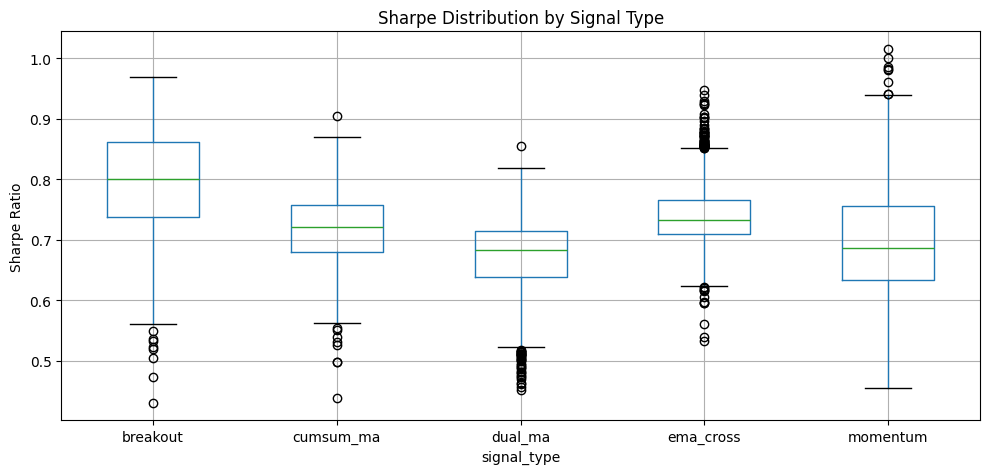

In [3]:
if len(singles) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    singles.boxplot(column='sharpe', by='signal_type', ax=ax)
    ax.set_title('Sharpe Distribution by Signal Type')
    ax.set_ylabel('Sharpe Ratio')
    plt.suptitle('')
    plt.tight_layout()

## 2. Top 20 single signals

In [4]:
if len(singles) > 0:
    decade_cols = [c for c in singles.columns if c.startswith('sharpe_')]
    cat_cols = [c for c in singles.columns if c.startswith('cat_sharpe_')]
    display_cols = ['signal_type', 'vol_window', 'smoothing', 'param1', 'param2',
                    'sharpe', 'max_dd'] + decade_cols + cat_cols
    display(
        singles
        .sort_values('sharpe', ascending=False)
        .head(20)[display_cols]
        .reset_index(drop=True)
        .style.format('{:.3f}', subset=[c for c in display_cols if c not in ['signal_type', 'vol_window', 'smoothing', 'param1', 'param2']])
        .background_gradient(subset=['sharpe'], cmap='RdYlGn')
    )

,signal_type,vol_window,smoothing,param1,param2,sharpe,max_dd,sharpe_1980,sharpe_1990,sharpe_2000,sharpe_2010,sharpe_2020,cat_sharpe_equities,cat_sharpe_bonds,cat_sharpe_hard,cat_sharpe_forex,cat_sharpe_soft
0,momentum,60,5,250.000000,nan,1.015,-0.252,0.342,1.435,1.147,0.809,0.866,0.356,0.651,0.638,0.319,0.674
1,momentum,60,1,250.000000,nan,1.001,-0.250,0.418,1.339,1.167,0.822,0.819,0.367,0.631,0.555,0.336,0.699
2,momentum,90,5,250.000000,nan,0.986,-0.242,0.072,1.405,1.154,0.854,0.766,0.351,0.644,0.633,0.309,0.623
3,momentum,90,1,250.000000,nan,0.982,-0.240,0.085,1.378,1.182,0.838,0.756,0.350,0.612,0.594,0.345,0.651
4,momentum,60,10,250.000000,nan,0.980,-0.254,0.271,1.469,1.125,0.739,0.783,0.350,0.639,0.595,0.294,0.660
5,breakout,60,10,250.000000,nan,0.969,-0.160,1.038,1.647,0.958,0.588,0.669,0.359,0.638,0.619,0.400,0.560
6,breakout,60,1,250.000000,nan,0.969,-0.163,1.032,1.608,0.944,0.608,0.714,0.321,0.612,0.638,0.361,0.650
7,momentum,120,5,250.000000,nan,0.960,-0.207,0.094,1.284,1.128,0.873,0.776,0.345,0.589,0.661,0.309,0.600
8,breakout,60,20,250.000000,nan,0.958,-0.162,0.952,1.576,0.957,0.613,0.684,0.347,0.610,0.610,0.401,0.570
9,breakout,90,1,250.000000,nan,0.949,-0.157,0.998,1.516,0.934,0.638,0.721,0.311,0.599,0.629,0.354,0.639


## 3. Heatmaps: Sharpe vs parameters (per signal type)

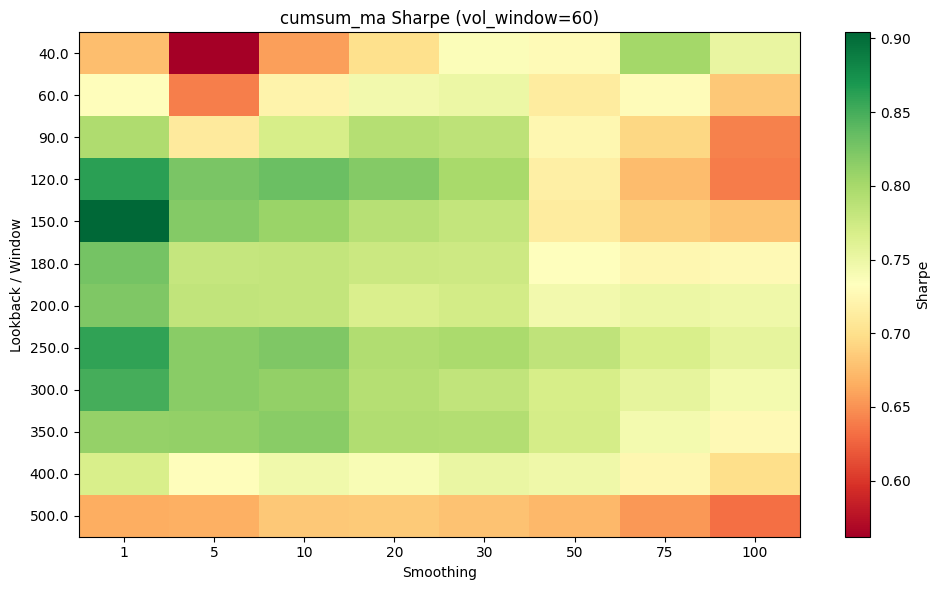

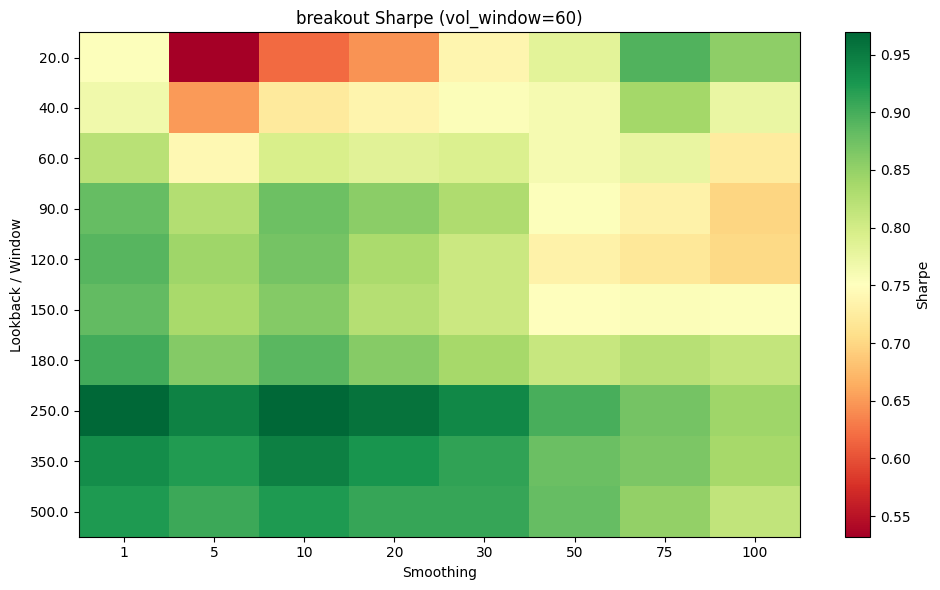

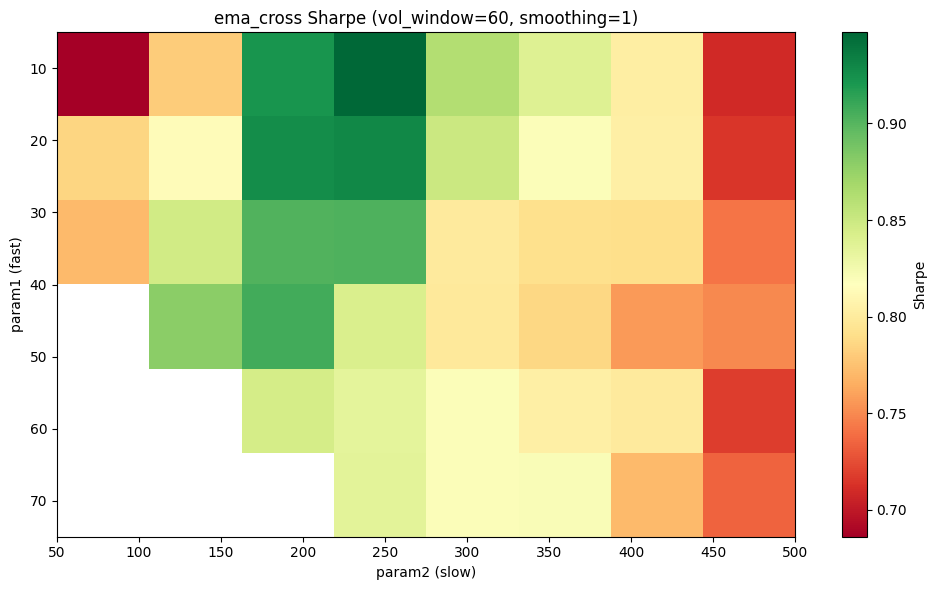

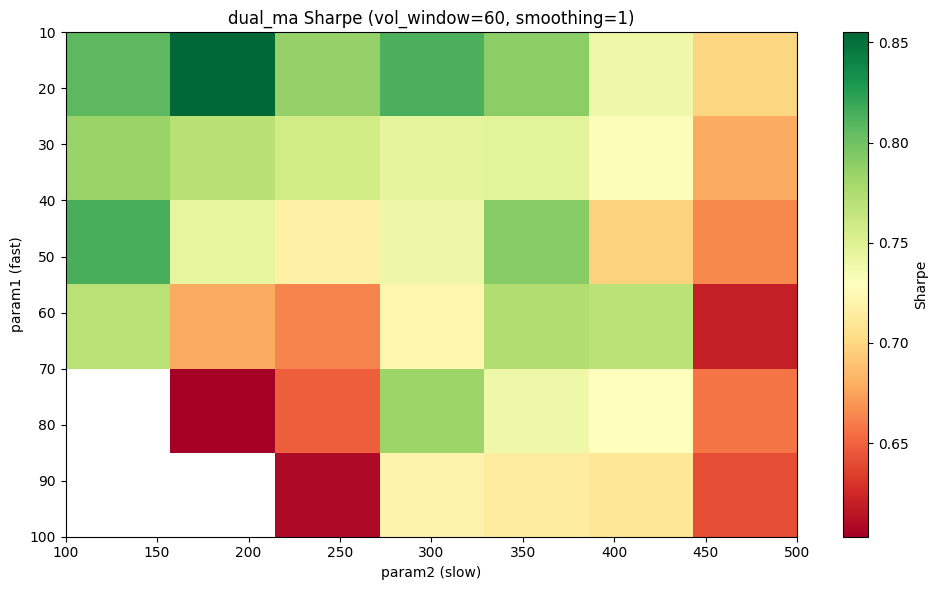

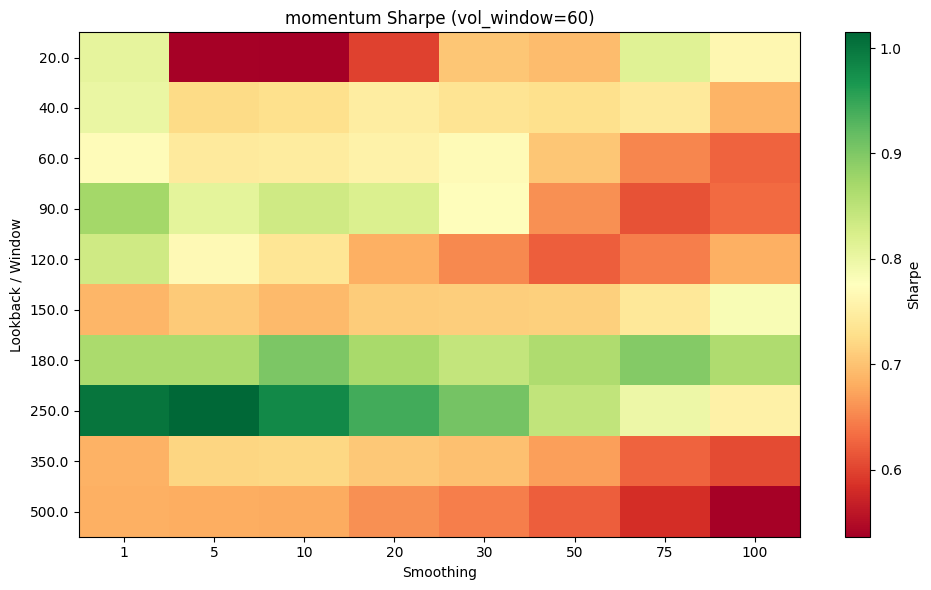

In [5]:
if len(singles) > 0:
    for stype in singles.signal_type.unique():
        sub = singles[singles.signal_type == stype]
        # Find best vol_window for this signal type
        best_vw = sub.groupby('vol_window').sharpe.median().idxmax()
        sub_vw = sub[sub.vol_window == best_vw]
        
        if 'param2' in sub_vw.columns and sub_vw.param2.nunique() > 1:
            # 2-param signal: heatmap of param1 vs param2 at best smoothing
            best_sm = sub_vw.groupby('smoothing').sharpe.median().idxmax()
            pivot = sub_vw[sub_vw.smoothing == best_sm].pivot_table(
                values='sharpe', index='param1', columns='param2', aggfunc='mean'
            )
            fig, ax = plt.subplots(figsize=(10, 6))
            im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                          extent=[pivot.columns[0], pivot.columns[-1],
                                  pivot.index[-1], pivot.index[0]])
            ax.set_xlabel('param2 (slow)')
            ax.set_ylabel('param1 (fast)')
            ax.set_title(f'{stype} Sharpe (vol_window={best_vw}, smoothing={best_sm})')
            plt.colorbar(im, ax=ax, label='Sharpe')
        else:
            # 1-param signal: heatmap of param1 vs smoothing
            pivot = sub_vw.pivot_table(
                values='sharpe', index='param1', columns='smoothing', aggfunc='mean'
            )
            fig, ax = plt.subplots(figsize=(10, 6))
            im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_xlabel('Smoothing')
            ax.set_ylabel('Lookback / Window')
            ax.set_title(f'{stype} Sharpe (vol_window={best_vw})')
            plt.colorbar(im, ax=ax, label='Sharpe')
        plt.tight_layout()
        plt.show()

## 4. Volatility window effect

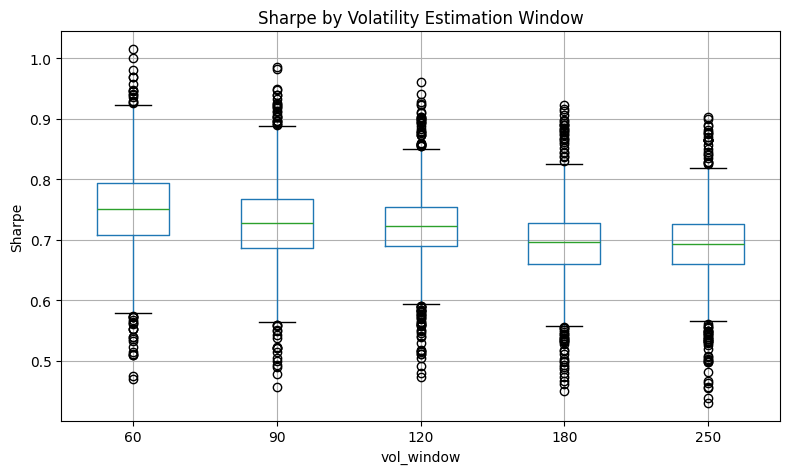

In [6]:
if len(singles) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    singles.boxplot(column='sharpe', by='vol_window', ax=ax)
    ax.set_title('Sharpe by Volatility Estimation Window')
    ax.set_ylabel('Sharpe')
    plt.suptitle('')
    plt.tight_layout()

## 5. Per-category best signals

,signal_type,vol_window,smoothing,param1,param2,sharpe,max_dd
category,,,,,,,
soft,momentum,60,1,250.0,100.0,0.699242,-0.244679
hard,momentum,60,1,20.0,100.0,0.698047,-0.383092
bonds,momentum,60,10,180.0,100.0,0.679599,-0.261300
equities,dual_ma,250,100,100.0,200.0,0.508253,-0.380075
forex,ema_cross,60,5,30.0,75.0,0.423016,-0.300542


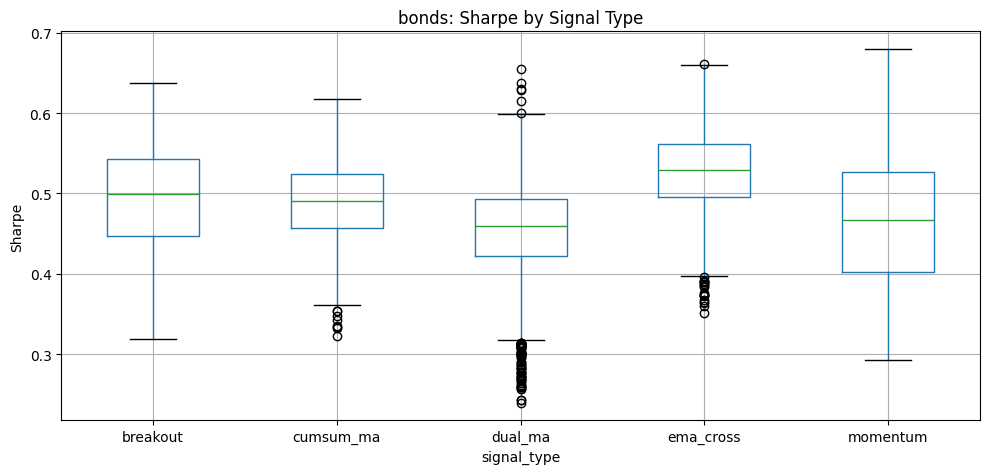

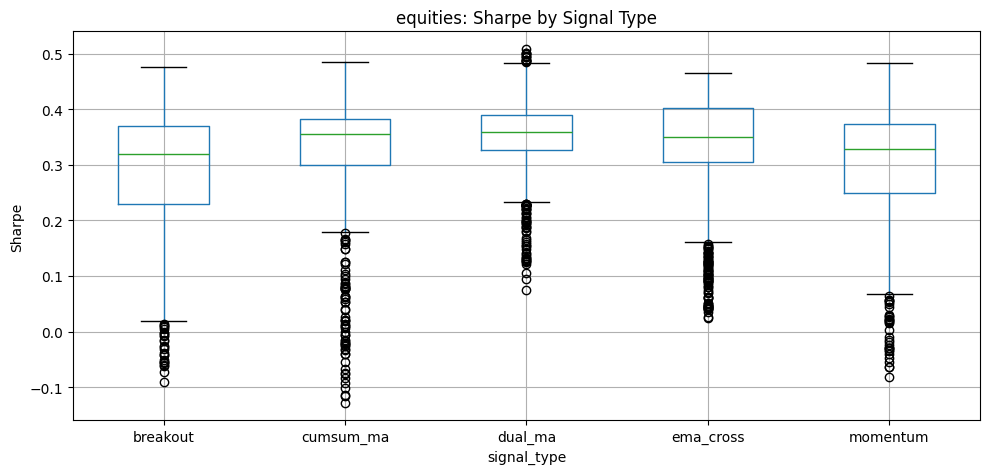

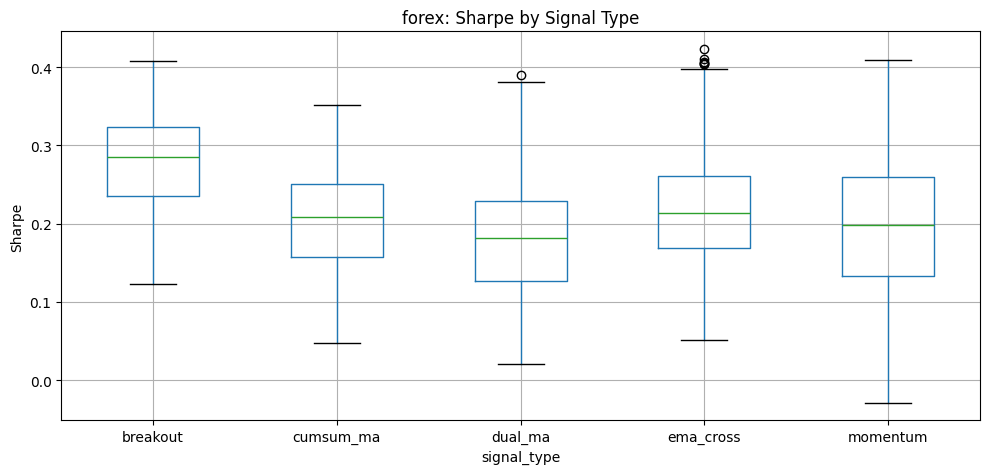

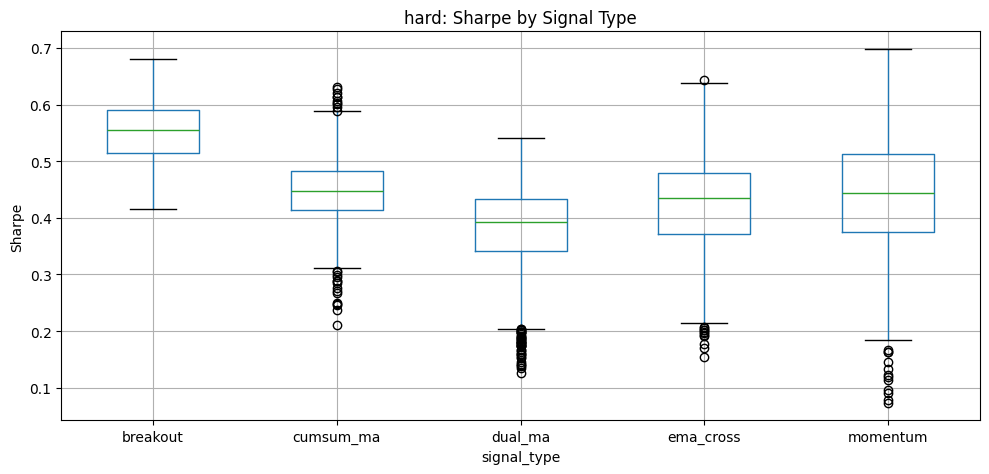

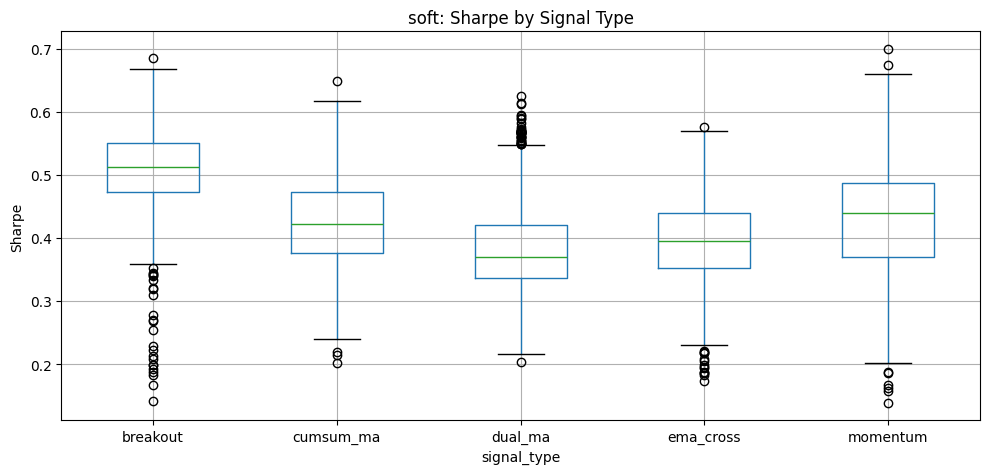

In [7]:
if len(by_cat) > 0:
    best_per_cat = (
        by_cat
        .sort_values('sharpe', ascending=False)
        .groupby('category').first()
        .sort_values('sharpe', ascending=False)
    )
    display(best_per_cat[['signal_type', 'vol_window', 'smoothing', 'param1', 'param2', 'sharpe', 'max_dd']])
    
    # Heatmap per category
    for cat in by_cat.category.unique():
        cat_df = by_cat[by_cat.category == cat]
        fig, ax = plt.subplots(figsize=(10, 5))
        cat_df.boxplot(column='sharpe', by='signal_type', ax=ax)
        ax.set_title(f'{cat}: Sharpe by Signal Type')
        ax.set_ylabel('Sharpe')
        plt.suptitle('')
        plt.tight_layout()
        plt.show()

## 6. Composite portfolio (best per category)

,category,signal_type,vol_window,smoothing,window,sharpe,fast_window,slow_window,fast_span,slow_span
0,bonds,momentum,60.0,10.0,180.0,0.679599,NaN,NaN,NaN,NaN
1,equities,dual_ma,250.0,100.0,NaN,0.508253,100.0,200.0,NaN,NaN
2,forex,ema_cross,60.0,5.0,NaN,0.423016,NaN,NaN,30.0,75.0
3,hard,momentum,60.0,1.0,20.0,0.698047,NaN,NaN,NaN,NaN
4,soft,momentum,60.0,1.0,250.0,0.699242,NaN,NaN,NaN,NaN
5,COMPOSITE,blend,NaN,NaN,NaN,1.230485,NaN,NaN,NaN,NaN


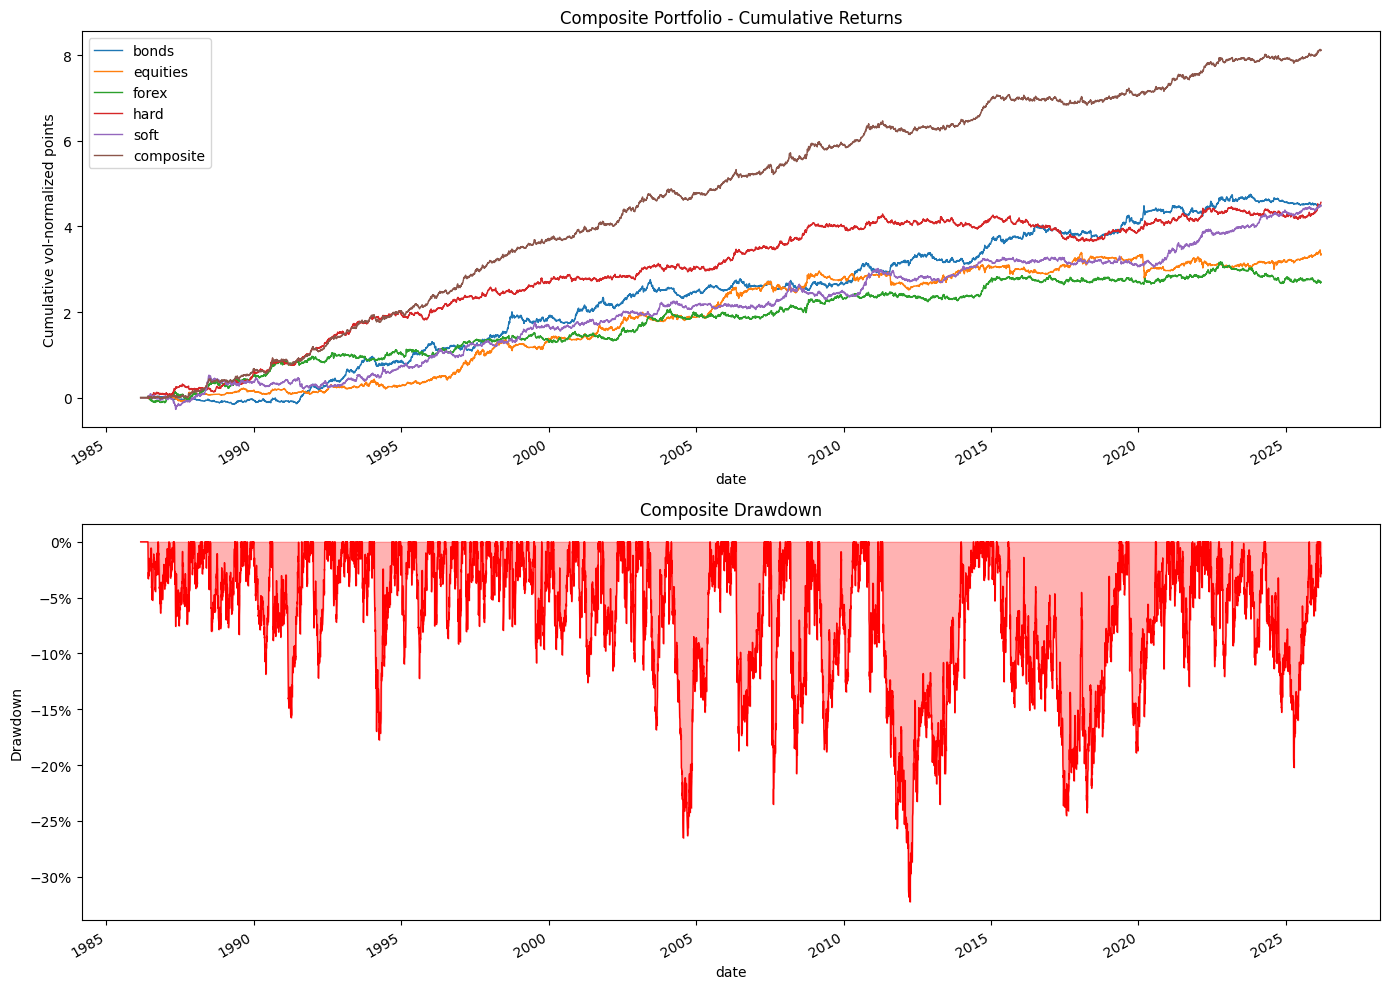

In [19]:
if len(composite) > 0:
    display(composite)

if len(composite_pnl) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Equity curve
    ax = axes[0]
    composite_pnl.cumsum().plot(ax=ax, lw=1)
    ax.set_title('Composite Portfolio - Cumulative Returns')
    ax.set_ylabel('Cumulative vol-normalized points')
    ax.legend(loc='upper left')
    
    # Drawdown
    ax = axes[1]
    cum = composite_pnl['composite'].cumsum()
    dd = cum - cum.cummax()
    dd.plot(ax=ax, color='red', lw=1)
    ax.fill_between(dd.index, dd, 0, alpha=0.3, color='red')
    ax.set_title('Composite Drawdown')
    ax.set_ylabel('Drawdown')
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    
    plt.tight_layout()

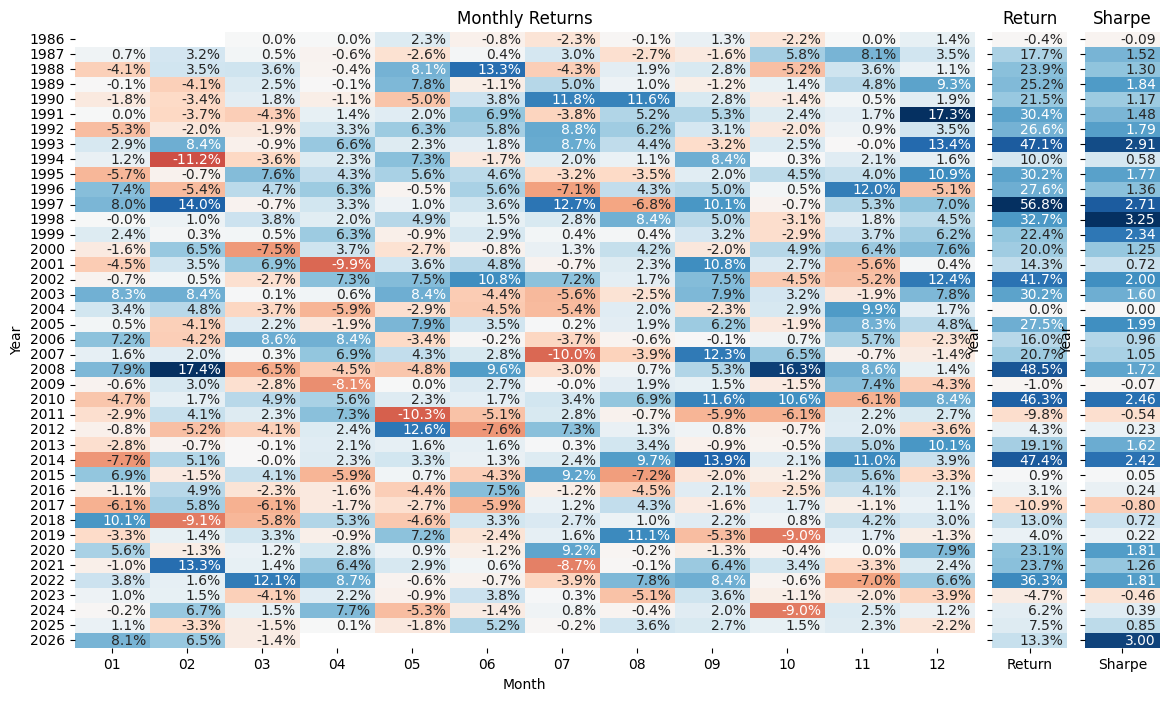

In [18]:
if len(composite_pnl) > 0:
    daily = composite_pnl['composite']
    monthly = daily.resample('ME').sum()
    monthly.index = monthly.index.to_period('M')

    monthly_ret = monthly.groupby([monthly.index.year, monthly.index.month]).first().unstack()
    monthly_ret.index.name = 'Year'
    monthly_ret.columns = [f'{m:02d}' for m in monthly_ret.columns]

    annual_ret = monthly_ret.sum(axis=1).rename('Return')
    annual_sharpe = (monthly_ret.mean(axis=1) / monthly_ret.std(axis=1) * np.sqrt(12)).rename('Sharpe')
    annuals = pd.concat([annual_ret, annual_sharpe], axis=1)

    fig, (ax1, ax2, ax3) = plt.subplots(
        ncols=3, sharey=True, figsize=(14, 8), width_ratios=[12, 1, 1],
        gridspec_kw={'wspace': 0.05}
    )

    common = dict(cmap='RdBu', center=0, cbar=False, annot=True, annot_kws={"ha": "right"})

    sns.heatmap(monthly_ret, ax=ax1, fmt=".1%", **common)
    ax1.set_title("Monthly Returns")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Year")

    sns.heatmap(annuals[['Return']], ax=ax2, fmt=".1%", **common)
    ax2.set_title("Return")
    ax2.set_xlabel("")

    sns.heatmap(annuals[['Sharpe']], ax=ax3, fmt=".2f", **common)
    ax3.set_title("Sharpe")
    ax3.set_xlabel("")

    for t in (t for ax in [ax1, ax2, ax3] for t in ax.texts):
        trans = t.get_transform()
        offs = mtrans.ScaledTranslation(0.45, 0., mtrans.IdentityTransform())
        t.set_transform(offs + trans)

## 7. ES overlay

Best combined Sharpe: 0.982
Best ES-only Sharpe: 0.472


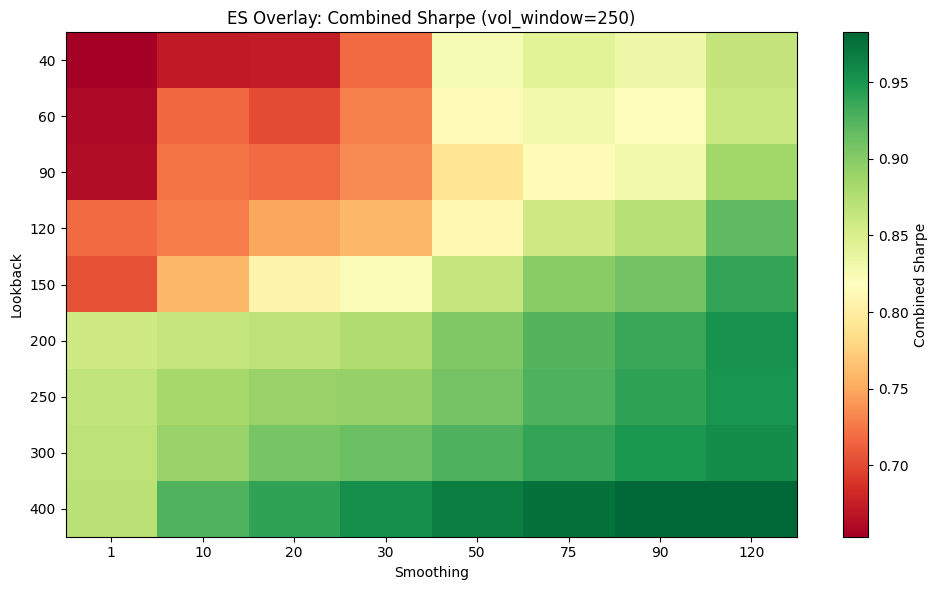

In [10]:
if len(es_overlay) > 0:
    print(f'Best combined Sharpe: {es_overlay.combined_sharpe.max():.3f}')
    print(f'Best ES-only Sharpe: {es_overlay.es_sharpe.max():.3f}')
    
    best_vw = es_overlay.groupby('vol_window').combined_sharpe.median().idxmax()
    sub = es_overlay[es_overlay.vol_window == best_vw]
    
    pivot = sub.pivot_table(values='combined_sharpe', index='lookback', columns='smoothing')
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Smoothing')
    ax.set_ylabel('Lookback')
    ax.set_title(f'ES Overlay: Combined Sharpe (vol_window={best_vw})')
    plt.colorbar(im, ax=ax, label='Combined Sharpe')
    plt.tight_layout()

## 8. Blend analysis

Top 10 blends:


,idx_a,idx_b,type_a,type_b,sharpe_a,sharpe_b,blend_sharpe,max_dd,improvement
0,0,25,momentum,momentum,1.014877,0.925769,1.089909,-0.181508,0.075031
1,1,25,momentum,momentum,1.000554,0.925769,1.079500,-0.184668,0.078947
2,4,25,momentum,momentum,0.980051,0.925769,1.075317,-0.202721,0.095266
3,0,29,momentum,ema_cross,1.014877,0.922169,1.074928,-0.145031,0.060050
4,2,25,momentum,momentum,0.985644,0.925769,1.069181,-0.175177,0.083537
5,0,24,momentum,ema_cross,1.014877,0.925854,1.068280,-0.154313,0.053403
6,1,29,momentum,ema_cross,1.000554,0.922169,1.065005,-0.143190,0.064451
7,3,25,momentum,momentum,0.982437,0.925769,1.063942,-0.170413,0.081505
8,14,25,momentum,momentum,0.941271,0.925769,1.063718,-0.214683,0.122447
9,4,29,momentum,ema_cross,0.980051,0.922169,1.061577,-0.155279,0.081526


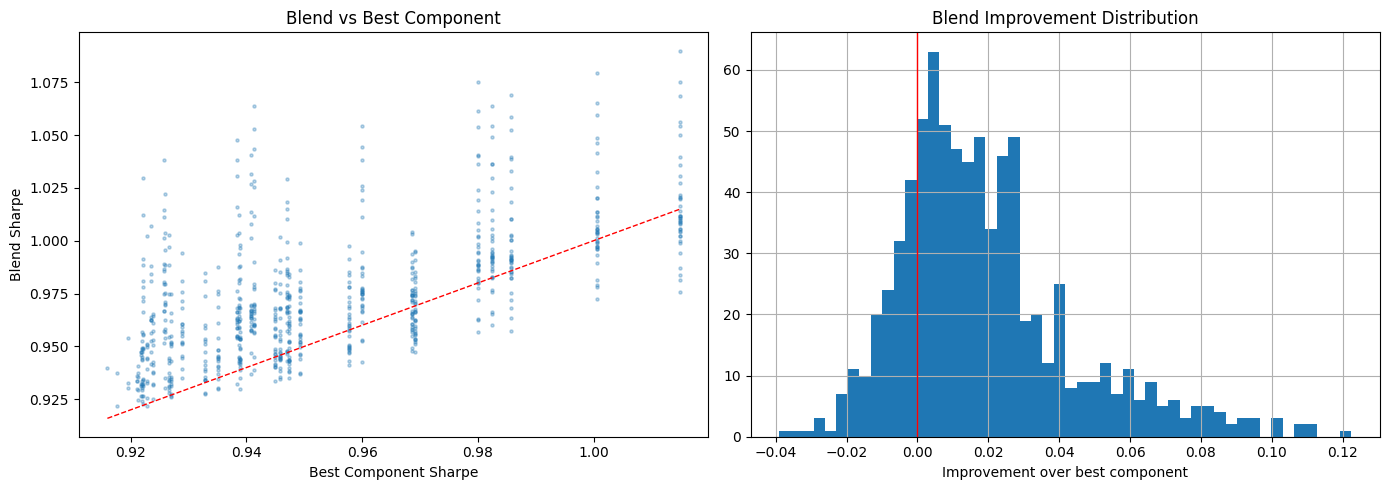

In [11]:
if len(blends) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    best_component = blends[['sharpe_a', 'sharpe_b']].max(axis=1)
    ax.scatter(best_component, blends.blend_sharpe, alpha=0.3, s=5)
    lims = [best_component.min(), best_component.max()]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel('Best Component Sharpe')
    ax.set_ylabel('Blend Sharpe')
    ax.set_title('Blend vs Best Component')
    
    ax = axes[1]
    blends.improvement.hist(bins=50, ax=ax)
    ax.axvline(0, color='red', lw=1)
    ax.set_xlabel('Improvement over best component')
    ax.set_title('Blend Improvement Distribution')
    
    plt.tight_layout()
    
    print('Top 10 blends:')
    display(
        blends.sort_values('blend_sharpe', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

## 9. Bootstrap confidence intervals

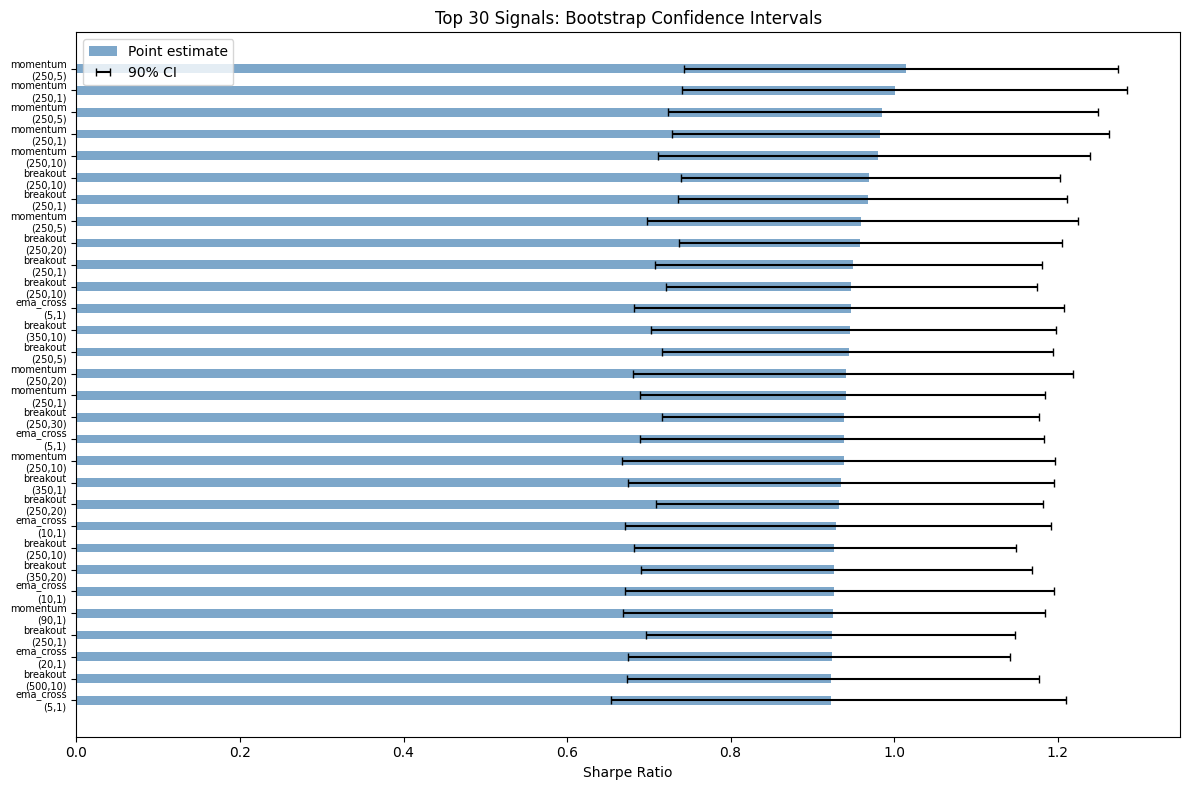

In [12]:
if len(bootstrap) > 0:
    boot = bootstrap.sort_values('sharpe', ascending=False).head(30).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    labels = boot.apply(lambda r: f"{r.signal_type}\n({int(r.param1)},{int(r.smoothing)})", axis=1)
    y = range(len(boot))
    
    ax.barh(y, boot.sharpe, height=0.4, color='steelblue', alpha=0.7, label='Point estimate')
    ax.errorbar(boot.boot_50pct, y, 
                xerr=[boot.boot_50pct - boot.boot_5pct, boot.boot_95pct - boot.boot_50pct],
                fmt='none', color='black', capsize=3, label='90% CI')
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('Sharpe Ratio')
    ax.set_title('Top 30 Signals: Bootstrap Confidence Intervals')
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()

## 10. Dense grid (fine-tuning around best regions)

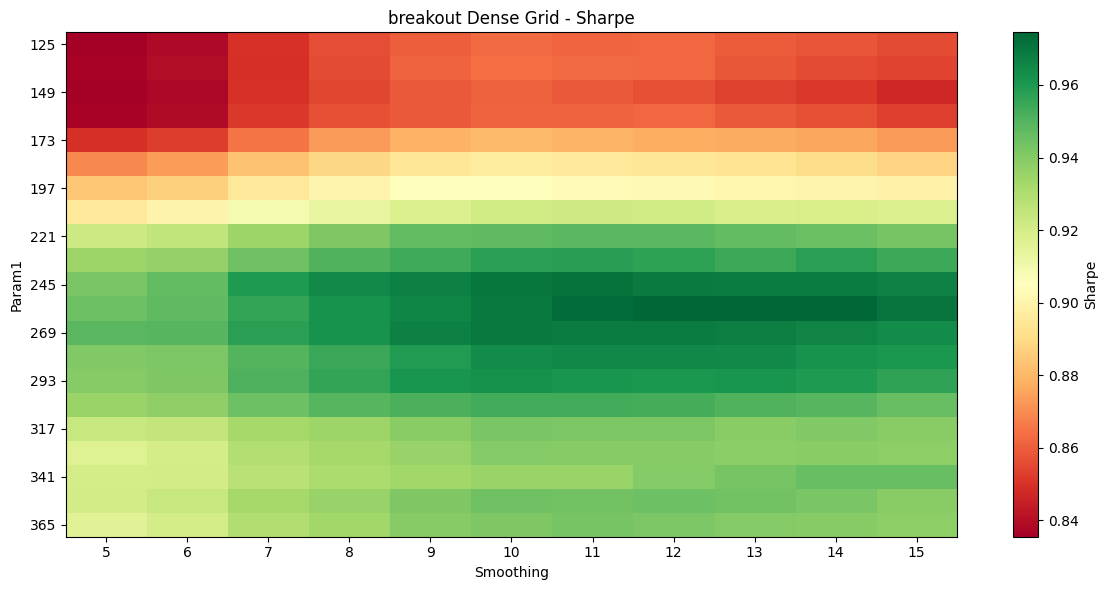

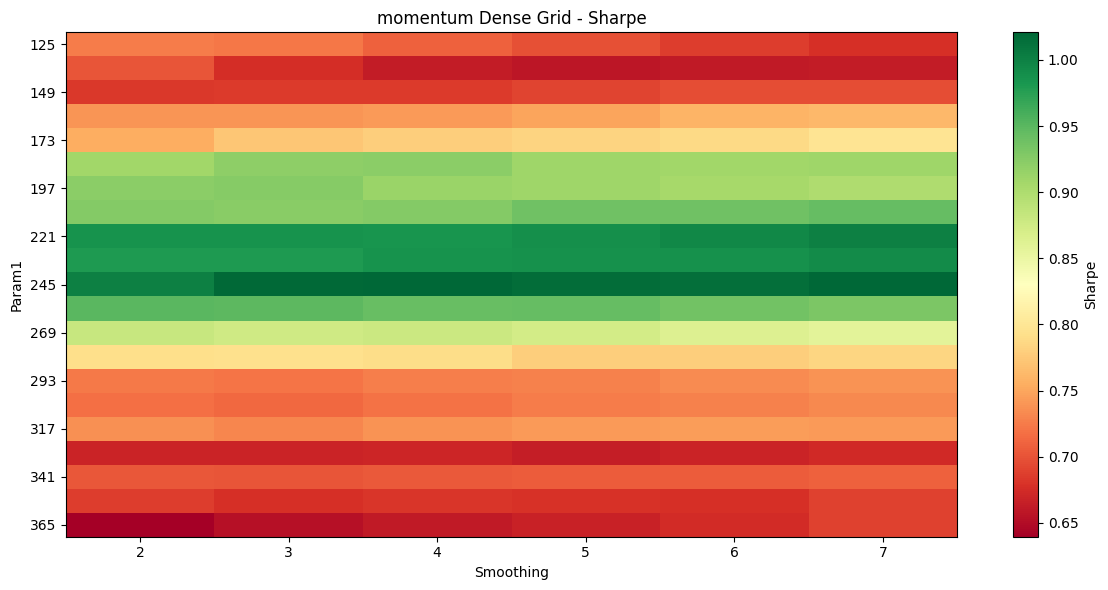


Dense grid top 10:


,signal_type,vol_window,smoothing,param1,param2,sharpe,max_dd
0,momentum,60,4,245,NaN,1.020890,-0.251840
1,momentum,60,7,245,NaN,1.020072,-0.252899
2,momentum,60,3,245,NaN,1.018655,-0.251535
3,momentum,60,5,245,NaN,1.015868,-0.252158
4,momentum,60,6,245,NaN,1.013466,-0.252793
5,momentum,60,2,245,NaN,1.000425,-0.257520
6,momentum,60,7,221,NaN,1.000419,-0.207965
7,momentum,60,6,221,NaN,0.994424,-0.209052
8,momentum,60,7,233,NaN,0.991512,-0.242321
9,momentum,60,5,221,NaN,0.989583,-0.207669


In [13]:
if len(dense) > 0:
    for stype in dense.signal_type.unique():
        sub = dense[dense.signal_type == stype]
        pivot = sub.pivot_table(values='sharpe', index='param1', columns='smoothing', aggfunc='mean')
        fig, ax = plt.subplots(figsize=(12, 6))
        im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
        # Label every 5th tick
        ax.set_xticks(range(0, len(pivot.columns), max(1, len(pivot.columns)//10)))
        ax.set_xticklabels([pivot.columns[i] for i in range(0, len(pivot.columns), max(1, len(pivot.columns)//10))])
        ax.set_yticks(range(0, len(pivot.index), max(1, len(pivot.index)//10)))
        ax.set_yticklabels([pivot.index[i] for i in range(0, len(pivot.index), max(1, len(pivot.index)//10))])
        ax.set_xlabel('Smoothing')
        ax.set_ylabel('Param1')
        ax.set_title(f'{stype} Dense Grid - Sharpe')
        plt.colorbar(im, ax=ax, label='Sharpe')
        plt.tight_layout()
        plt.show()
    
    print('\nDense grid top 10:')
    display(
        dense.sort_values('sharpe', ascending=False)
        .head(10)[['signal_type', 'vol_window', 'smoothing', 'param1', 'param2', 'sharpe', 'max_dd']]
        .reset_index(drop=True)
    )

## 11. Decade stability

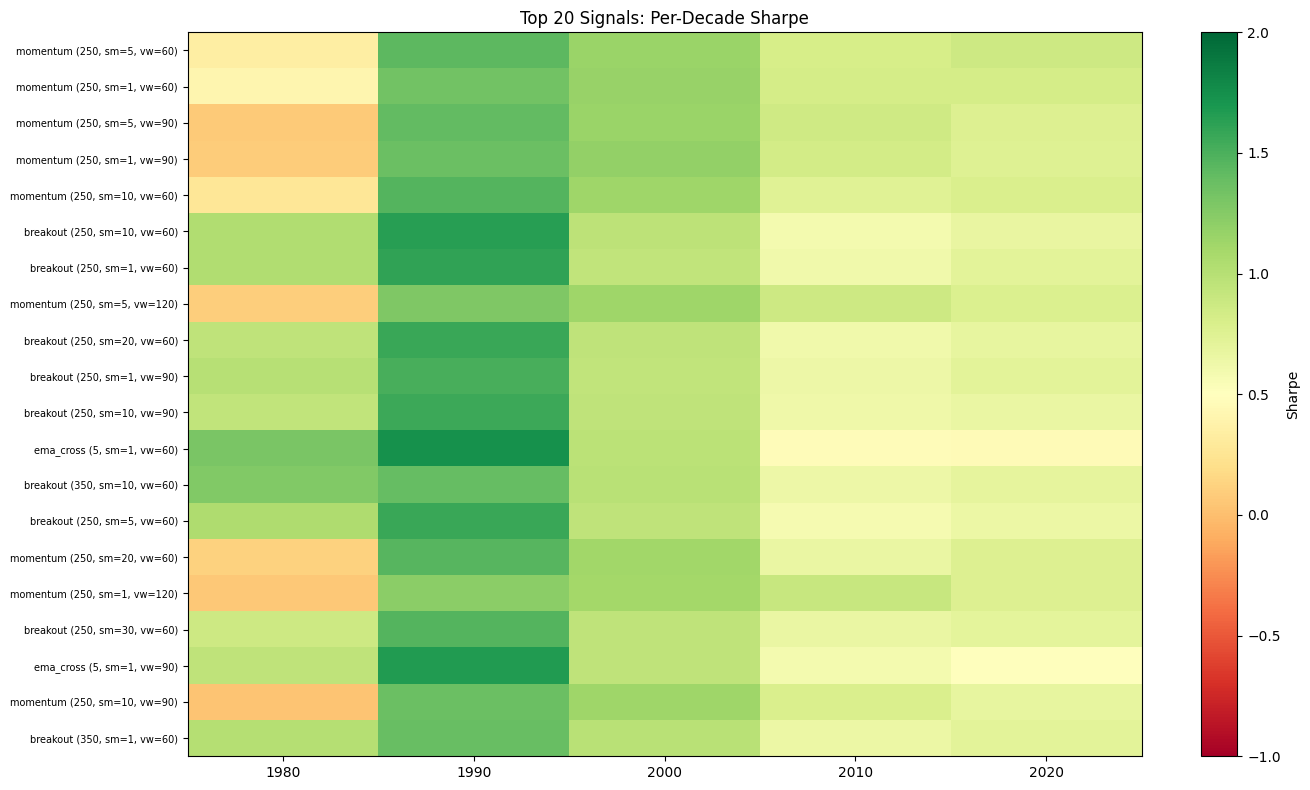

In [14]:
if len(singles) > 0:
    decade_cols = [c for c in singles.columns if c.startswith('sharpe_') and not c.startswith('sharpe_stability')]
    top20 = singles.sort_values('sharpe', ascending=False).head(20)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    data = top20[decade_cols].values
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=2)
    ax.set_xticks(range(len(decade_cols)))
    ax.set_xticklabels([c.replace('sharpe_', '') for c in decade_cols])
    labels = top20.apply(lambda r: f"{r.signal_type} ({int(r.param1)}, sm={int(r.smoothing)}, vw={int(r.vol_window)})", axis=1)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title('Top 20 Signals: Per-Decade Sharpe')
    plt.colorbar(im, ax=ax, label='Sharpe')
    plt.tight_layout()

## 12. Summary statistics

In [15]:
if len(singles) > 0:
    summary = (
        singles
        .groupby('signal_type')
        .agg(
            count=('sharpe', 'count'),
            sharpe_mean=('sharpe', 'mean'),
            sharpe_median=('sharpe', 'median'),
            sharpe_max=('sharpe', 'max'),
            sharpe_std=('sharpe', 'std'),
            max_dd_median=('max_dd', 'median'),
        )
        .sort_values('sharpe_median', ascending=False)
    )
    display(summary.style.format('{:.3f}', subset=summary.columns[1:]))

,count,sharpe_mean,sharpe_median,sharpe_max,sharpe_std,max_dd_median
signal_type,,,,,,
breakout,400,0.793,0.800,0.969,0.088,-0.238
ema_cross,1680,0.740,0.733,0.947,0.051,-0.281
cumsum_ma,480,0.716,0.721,0.904,0.065,-0.284
momentum,400,0.700,0.686,1.015,0.100,-0.299
dual_ma,1560,0.674,0.683,0.855,0.062,-0.315
